# SchwarMAX — analysing an MCMC run

This notebook walks through everything you do **after** an MCMC run with
`SchwarMAX` has finished:

1. **Posterior corner plot**
2. **Data vs model** — compare the best-fit forward model to the IFU
   maps (Σ\_★, V_los, σ_v, h₃, h₄)
3. **Rotation curve + DM enclosed mass** — recover v_c(R) and the dark
   matter mass profile from the posterior, and compare to the N-body
   ground truth.
4. **Orbital structure** — sample orbits from the best-fit model and
   compare their circularity distribution P(λ_z | R) to the N-body one.

## Imports

Imports, file paths, the forward-model definition (density + potential),
and a couple of helpers that turn a 12-D parameter vector into the dicts
that `SchwarMAX` expects.


In [2]:
# --- standard libs ---
import os, sys, pickle
from functools import partial
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm

# --- schwarmax_pkg ---
PKG_DIR = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if PKG_DIR not in sys.path:
    sys.path.insert(0, PKG_DIR)

from utils import (
    load_data_bootstrap,
    logMenc_logc_to_logM_logRs, logM_logRs_to_logMenc_logc,
    get_rotation_curve, build_Lcirc_of_E, makeRotationMatrix,
)
from model import build_model, get_model_with_orbit
from potentials import (
    NFW_potential,
    MiyamotoNagai_potential, MiyamotoNagai_density,
)
from dehnen_bar import T3_potential, T3_density, V4_potential, V4_density
from constants import KPCGYR_TO_KMS, EPSILON

# --- plot defaults ---
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12

print('schwarmax_pkg loaded from', PKG_DIR)
print('JAX devices:', jax.devices())


schwarmax_pkg loaded from /Users/hanyuan/Library/CloudStorage/Dropbox/python_script/schwarmax_pkg
JAX devices: [CpuDevice(id=0)]


In [3]:
# --- fixed bar / bulge shape parameters ---
V4_A, V4_B, V4_L, V4_GAMMA = 0.5, 0.5, 0.1, 0.0
GAMMA_BAR = 1.0


@jax.jit
def density_func(x, y, z, params):
    """Stellar density: Miyamoto-Nagai disc + T3 bar + V4 bulge."""
    mn_params = {k: params[k] for k in
                 ('logM_disc', 'Rs_disc', 'Hs_disc',
                  'x_origin', 'y_origin', 'z_origin',
                  'dirx', 'diry', 'dirz')}
    rho_mn = MiyamotoNagai_density(x, y, z, mn_params)
    M_bar = 10.0 ** params['logM_bar']
    rho_t3 = T3_density(x, y, z, M_bar, params['a_bar'], params['b_bar'],
                        params['L_bar'], GAMMA_BAR)
    rho_v4 = V4_density(x, y, z, M_bar, V4_A, V4_B, V4_L, V4_GAMMA)
    return rho_mn + rho_t3 + rho_v4


@jax.jit
def potential_func(x, y, z, params_baryon, params_halo):
    """Total potential: NFW halo + MN disc + T3 bar + V4 bulge."""
    phi_halo = NFW_potential(x, y, z, params_halo)
    mn_params = {k: params_baryon[k] for k in
                 ('logM_disc', 'Rs_disc', 'Hs_disc',
                  'x_origin', 'y_origin', 'z_origin',
                  'dirx', 'diry', 'dirz')}
    phi_mn = MiyamotoNagai_potential(x, y, z, mn_params)
    M_bar = 10.0 ** params_baryon['logM_bar']
    phi_t3 = T3_potential(x, y, z, M_bar, params_baryon['a_bar'],
                          params_baryon['b_bar'], params_baryon['L_bar'],
                          GAMMA_BAR)
    phi_v4 = V4_potential(x, y, z, M_bar, V4_A, V4_B, V4_L, V4_GAMMA)
    return phi_halo + phi_mn + phi_t3 + phi_v4


In [4]:
# --- parameter convention (12-D, matches the example checkpoint) ---
PARAM_NAMES_RAW = [
    'logM_10kpc', 'logM_disk', 'logM_bar', 'logc_halo',
    'logRs_disk', 'logHs_disk', 'logL_bar',
    'alpha', 'beta', 'gamma',
    'log_mass_to_light', 'log_Omega',
]
PARAM_NAMES_PLOT = [
    r'$\log M_{\rm DM, <10}$', r'$\log M_{\rm disc}$', r'$\log M_{\rm bar}$',
    r'$\log c_{\rm halo}$', r'$\log R_{s,\rm disc}$', r'$\log H_{s,\rm disc}$',
    r'$\log L_{\rm bar}$',
    r'$\alpha$ (deg)', r'$\beta$ (deg)', r'$\gamma$ (deg)',
    r'$\log_{10}\Upsilon$', r'$\Omega$ (km/s/kpc)',
]

# --- analytic ground truth (mock parameters used to generate the data) ---
GROUND_TRUTH_DICT = {
    'logM_halo': 11.88,
    'logM_disk': 10.83,
    'logM_bar':  10.20,
    'logRs_halo': np.log10(19.2),
    'logRs_disk': np.log10(12.0),
    'logHs_disk': np.log10(0.9),
    'logL_bar':   np.log10(4.87),
    'alpha': 25.0, 'beta': 65.0, 'gamma': 45.0,  # degrees
    'log_mass_to_light': 0.0,
    'Omega': 25.0,                                # km/s/kpc
}
logM10_gt, logc_gt = logM_logRs_to_logMenc_logc(
    GROUND_TRUTH_DICT['logM_halo'], GROUND_TRUTH_DICT['logRs_halo'])
GROUND_TRUTH_DICT['logM_10kpc'] = float(logM10_gt)
GROUND_TRUTH_DICT['logc_halo']  = float(logc_gt)

# Vector in PLOT units (rad->deg, log(Omega)->Omega, log(L/M)->log(Upsilon))
GROUND_TRUTH = np.array([
    GROUND_TRUTH_DICT['logM_10kpc'],
    GROUND_TRUTH_DICT['logM_disk'],
    GROUND_TRUTH_DICT['logM_bar'],
    GROUND_TRUTH_DICT['logc_halo'],
    GROUND_TRUTH_DICT['logRs_disk'],
    GROUND_TRUTH_DICT['logHs_disk'],
    GROUND_TRUTH_DICT['logL_bar'],
    GROUND_TRUTH_DICT['alpha'],     # deg
    GROUND_TRUTH_DICT['beta'],
    GROUND_TRUTH_DICT['gamma'],
    GROUND_TRUTH_DICT['log_mass_to_light'],  # already log(M/L) = log Upsilon
    GROUND_TRUTH_DICT['Omega'],
])


def unpack_params(theta):
    """12-D vector (raw MCMC units, angles in rad) -> halo/baryon dicts."""
    (logM_10kpc, logM_disk, logM_bar, logc_halo,
     logRs_disk, logHs_disk, logL_bar,
     alpha_rad, beta_rad, gamma_rad,
     log_ML, log_Omega) = [float(x) for x in theta]
    logM_halo, logRs_halo = logMenc_logc_to_logM_logRs(
        logM_10kpc, logc_halo, r_enc=10.0, Delta=200., rho_crit=277.54)
    L_bar = 10.0 ** logL_bar
    Hs    = 10.0 ** logHs_disk
    params_halo_pot = dict(
        logM=float(logM_halo), Rs=10.0**float(logRs_halo),
        a=1.0, b=1.0, c=1.0,
        x_origin=0.0, y_origin=0.0, z_origin=0.0,
        dirx=0.0, diry=0.0, dirz=1.0,
    )
    params_baryon_rho = dict(
        logM_disc=logM_disk, Rs_disc=10.0**logRs_disk, Hs_disc=Hs,
        logM_bar=logM_bar, L_bar=L_bar, a_bar=L_bar/5.0, b_bar=Hs,
        mass_to_light_ratio=10.0**log_ML,
        Omega_bar=10.0**log_Omega,
        x_origin=0.0, y_origin=0.0, z_origin=0.0,
        dirx=0.0, diry=0.0, dirz=1.0,
        alpha=alpha_rad * 180/np.pi,   # build_model expects degrees
        beta =beta_rad  * 180/np.pi,
        gamma=gamma_rad * 180/np.pi,
    )
    return params_halo_pot, params_baryon_rho


In [5]:
# --- file paths ---
EXAMPLE_DIR     = os.getcwd()                                    # ./example
CHECKPOINT_FILE = os.path.join(EXAMPLE_DIR,
    'mcmc_checkpoint_0629_beta65_gamma45_D50_gal2.pkl')
DATA_FILENAME   = 'mock_Nbody_bar_XY_withRot_Nbins600_beta65_gamma45_D50_gal2.pkl'
NBODY_DIR       = os.path.join(EXAMPLE_DIR, 'Bar_model_TG21', 'model')
NBODY_SNAPSHOT  = os.path.join(NBODY_DIR, 't_t0_7')
NBODY_POT_INI   = os.path.join(NBODY_DIR, 't_t0_7.ini')

# --- load the chain ---
# The example chain is 13-D: the first 12 are the model parameters
# listed in PARAM_NAMES_RAW; the 13th is log(sigma_amplifier), an
# inflation factor on the data errors used inside the likelihood. It
# doesn't enter the forward model, so we drop it everywhere except in
# the raw checkpoint.
with open(CHECKPOINT_FILE, 'rb') as f:
    ckpt = pickle.load(f)
all_samples_full = np.stack(ckpt['all_samples'], axis=0)   # (steps, chains, ndim)
all_logprob = np.stack(ckpt['all_logprob'], axis=0)
raw_ndim = all_samples_full.shape[-1]

# Two conventions exist in this codebase:
#   13-D: fit with the OLD likelihood (SchwarMAX/likelihoods_bar.py).
#         slot [12] is log_sigma_amplifier; param[10] = log10(L/M).
#         Drop slot [12] and flip the sign of param[10] so the rest
#         of the notebook can use the NEW convention.
#   12-D: fit with the NEW likelihood (schwarmax_pkg/likelihood.py).
#         param[10] is already log10(M/L) — no flip.
if raw_ndim == 13:
    print('Detected 13-D chain (OLD convention). Dropping log_sigma slot '
          'and flipping the sign of param[10].')
    all_samples = all_samples_full[..., :12].copy()
    all_samples[..., 10] = -all_samples[..., 10]
elif raw_ndim == 12:
    print('Detected 12-D chain (NEW convention). No sign flip needed.')
    all_samples = all_samples_full.copy()
else:
    raise ValueError(f'Unexpected chain ndim: {raw_ndim}')

print(f'Raw chain shape: {all_samples_full.shape}  (steps, chains, ndim)')
print(f'Model-parameter chain shape: {all_samples.shape}')
print(f'Last-step logP: max={all_logprob[-1].max():.2f}, '
      f'min={all_logprob[-1].min():.2f}')


Detected 12-D chain (NEW convention). No sign flip needed.
Raw chain shape: (1000, 32, 12)  (steps, chains, ndim)
Model-parameter chain shape: (1000, 32, 12)
Last-step logP: max=-226.16, min=-241.10


In [6]:
# --- load the mock data once (used by Sections 2 and 4) ---
dict_data = load_data_bootstrap(EXAMPLE_DIR + '/', DATA_FILENAME, n_samples=10_000)
print(f"Voronoi bins: {dict_data['total_bins']}")
print(f"IC particles: {dict_data['w0'].shape[0]}")


Voronoi bins: 609
IC particles: 10000


## 1. Posterior corner plot

We filter the chains to drop any that didn't converge (last-step
logP < max − 1000), discard the first `DISCARD=300` warm-up steps,
and convert angles to degrees and `log Ω` to `Ω` in km/s/kpc before
calling `corner.corner`.


In [7]:
import corner

DISCARD_CORNER = 300
THIN_CORNER    = 1
FILTER_LOGP_GAP = 1000.0   # keep chains within this of best last-step logP

n_steps, n_chains, ndim = all_samples.shape

# Filter divergent chains
last_lp = all_logprob[-1, :]
keep = last_lp > (last_lp.max() - FILTER_LOGP_GAP)
posterior = all_samples[:, keep, :].copy()
logprob   = all_logprob[:, keep].copy()
print(f'Kept {keep.sum()}/{n_chains} chains')

# Unit conversion to PLOT units. Order: angles in slots 7,8,9 are RAD;
# log(M/L) in slot 10 -> log(Upsilon) = -log(M/L); log(Omega) in slot
# 11 -> Omega in km/s/kpc.
posterior_plot = posterior.copy()
posterior_plot[..., 7]  = posterior_plot[..., 7]  * 180/np.pi
posterior_plot[..., 8]  = posterior_plot[..., 8]  * 180/np.pi
posterior_plot[..., 9]  = posterior_plot[..., 9]  * 180/np.pi
# slot [10] is already log(M/L) = log Upsilon after the convention flip in Section 0.
posterior_plot[..., 11] = 10**posterior_plot[..., 11] * KPCGYR_TO_KMS  # log Omega -> Omega km/s/kpc

flat_samples = posterior_plot[DISCARD_CORNER::THIN_CORNER, :, :].reshape(-1, ndim)
print(f'Flat sample shape after discard+thin: {flat_samples.shape}')

# Best fit (in PLOT units)
flat_lp = logprob[DISCARD_CORNER::THIN_CORNER, :].reshape(-1)
best_idx = int(np.argmax(flat_lp))
best_param_plot = flat_samples[best_idx]
best_logP = float(flat_lp[best_idx])

print(f'\nBest log-posterior: {best_logP:.3f}')
print(f"{'Parameter':>22s} {'best-fit':>10s} {'truth':>10s} {'median':>10s}")
for i, name in enumerate(PARAM_NAMES_RAW):
    print(f"{name:>22s} {best_param_plot[i]:10.4f} {GROUND_TRUTH[i]:10.4f} "
          f"{np.median(flat_samples[:, i]):10.4f}")


Kept 32/32 chains
Flat sample shape after discard+thin: (22400, 12)

Best log-posterior: -225.605
             Parameter   best-fit      truth     median
            logM_10kpc    10.8628    10.7653    10.8624
             logM_disk    11.2801    10.8300    11.0539
              logM_bar    10.2291    10.2000    10.2269
             logc_halo     0.8764     0.8879     0.8316
            logRs_disk     1.4482     1.0792     1.3030
            logHs_disk    -0.1339    -0.0458    -0.1368
              logL_bar     0.6979     0.6875     0.6681
                 alpha    25.0888    25.0000    25.0942
                  beta    65.7952    65.0000    65.6583
                 gamma    51.1447    45.0000    48.7975
     log_mass_to_light    -0.2139     0.0000    -0.2232
             log_Omega    25.5776    25.0000    26.1147


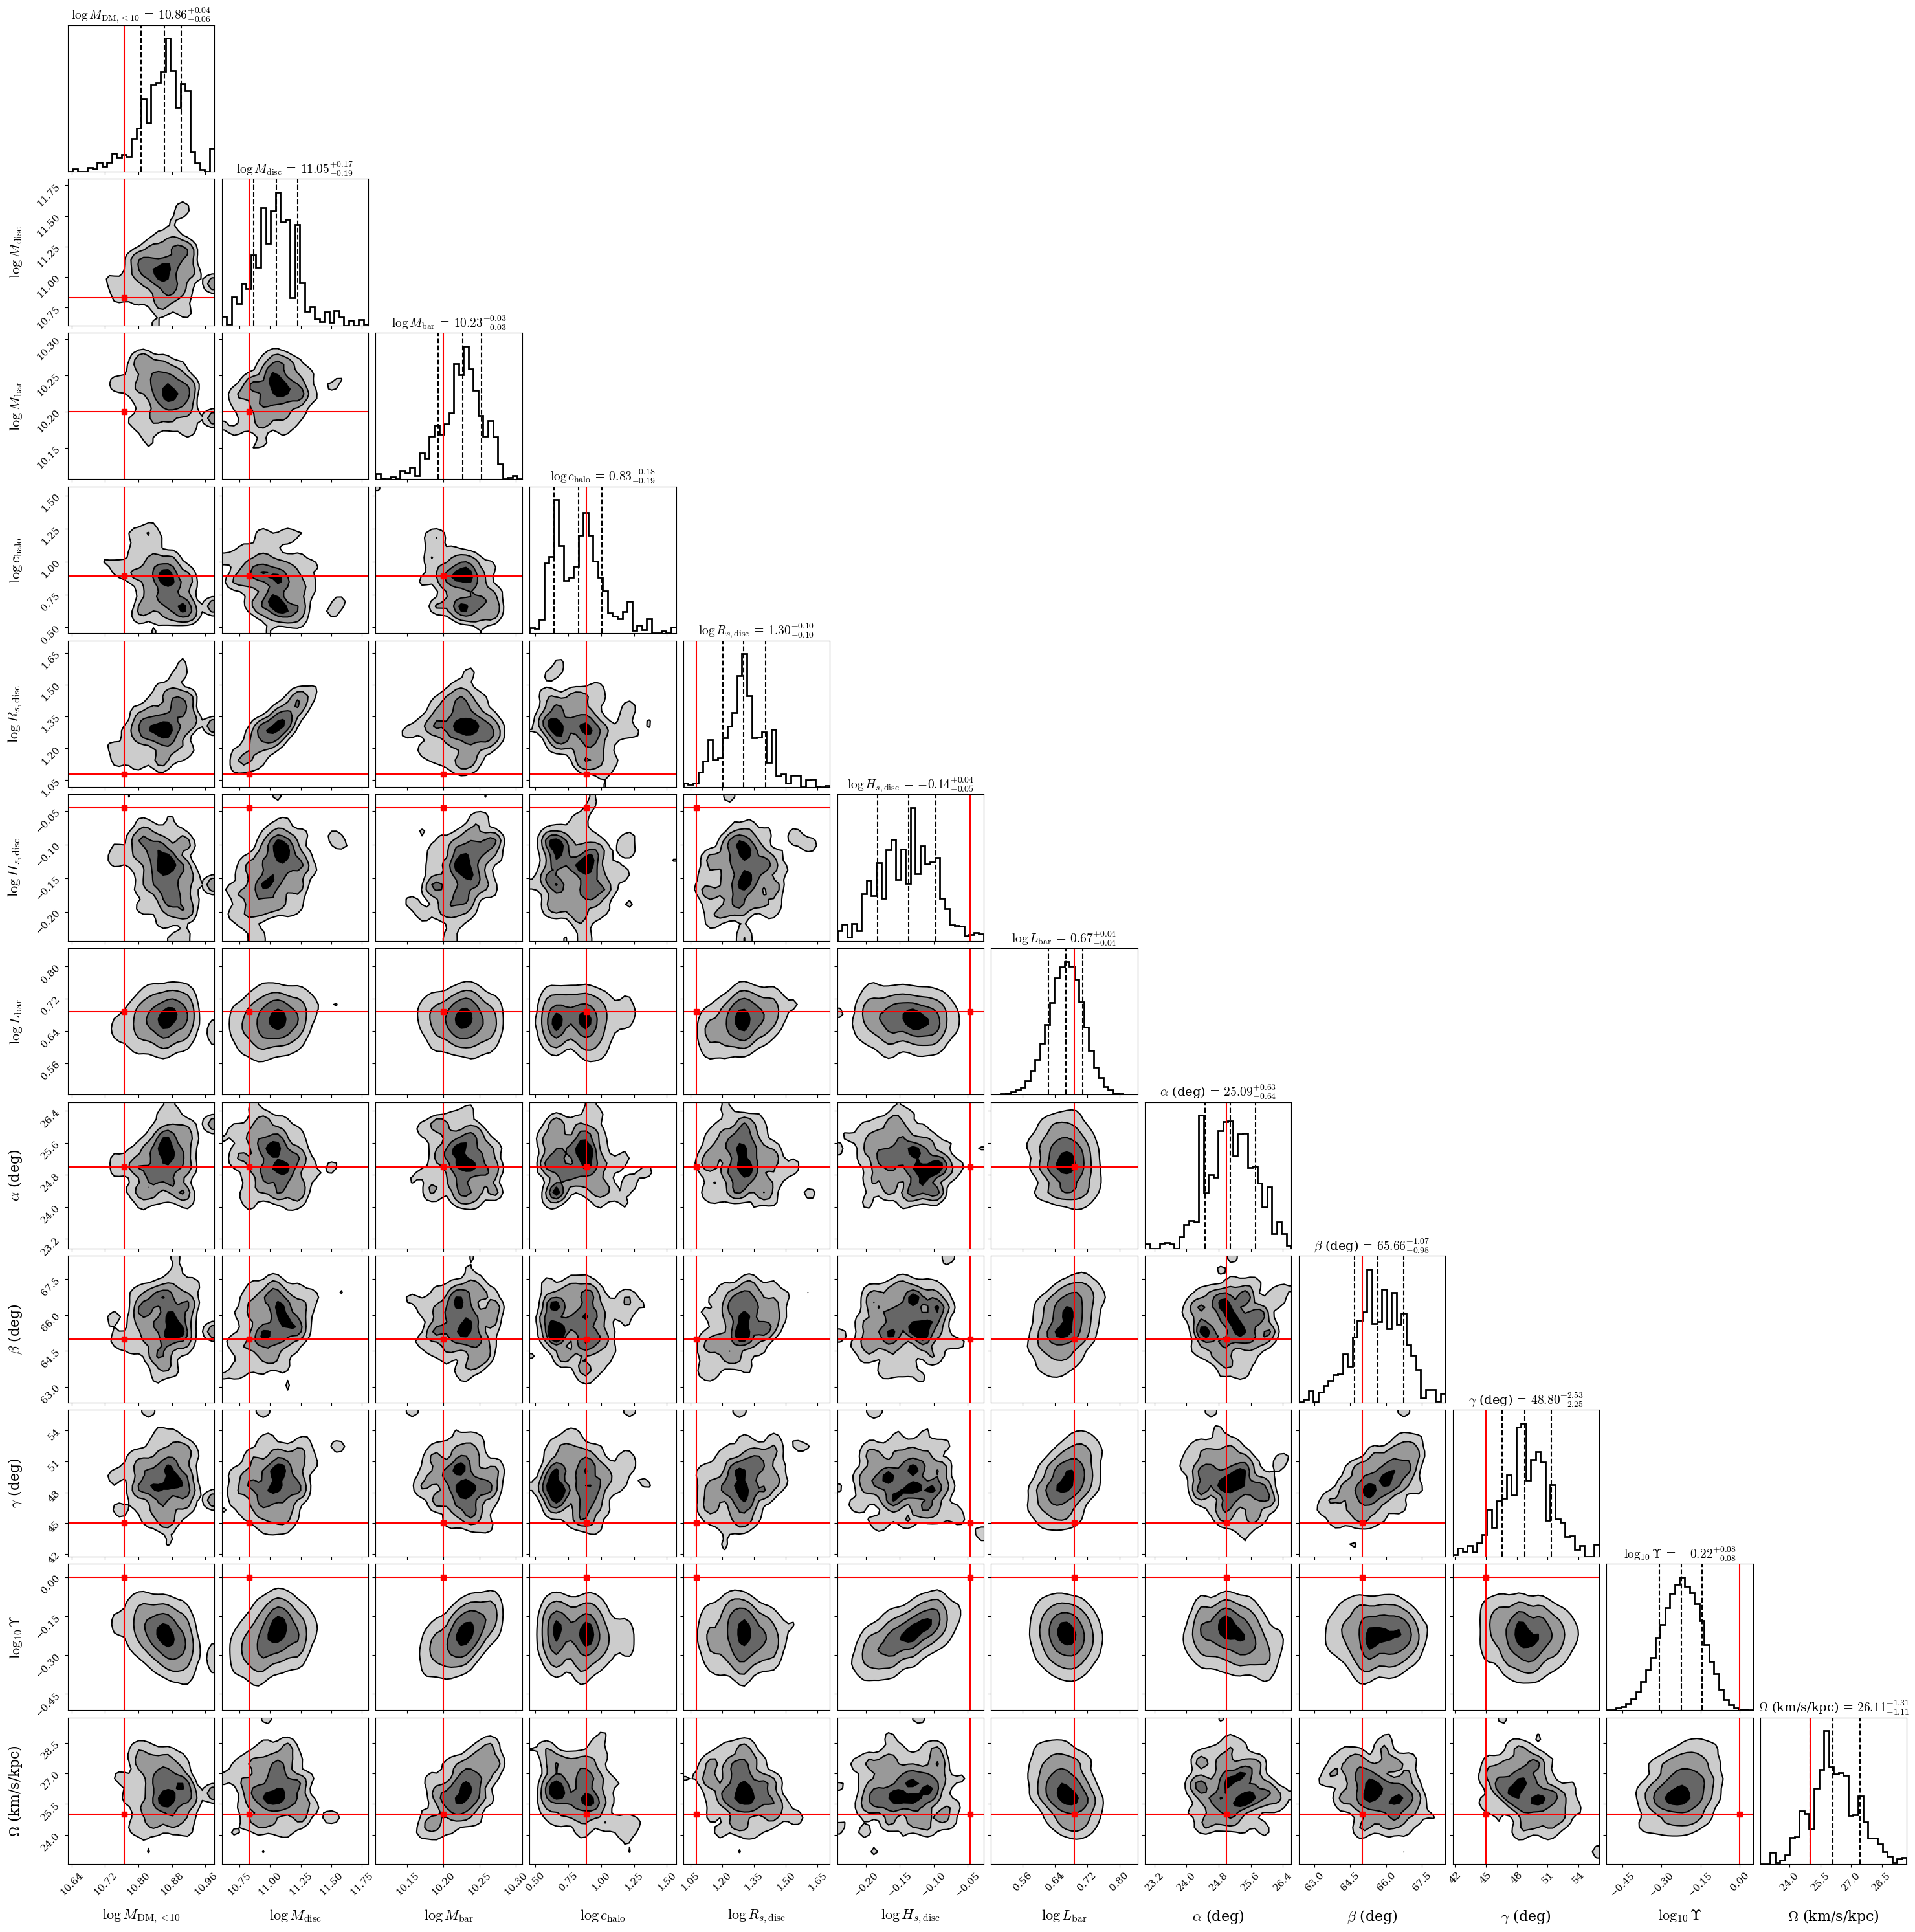

In [8]:
# Plot
fig = plt.figure(figsize=(2.5*ndim, 2.5*ndim))

# Slight jitter on logL_bar and log Upsilon so the discrete-looking
# chains read as a smooth posterior (visual cosmetic only).
flat_samples_jit = flat_samples.copy()
flat_samples_jit[:, 6]  = np.random.normal(flat_samples_jit[:, 6],  0.03)
flat_samples_jit[:, 10] = np.random.normal(flat_samples_jit[:, 10], 0.05)

# Use percentile ranges padded to include the truth, like the old script
ranges = []
for i in range(ndim):
    lo = min(flat_samples_jit[:, i].min(), GROUND_TRUTH[i] - 0.02)
    hi = max(flat_samples_jit[:, i].max(), GROUND_TRUTH[i] + 0.02)
    ranges.append((lo, hi))

corner.corner(
    flat_samples_jit,
    range=ranges,
    labels=PARAM_NAMES_PLOT,
    truths=GROUND_TRUTH,
    show_titles=True,
    title_fmt='.2f',
    title_kwargs={'fontsize': 14},
    label_kwargs={'fontsize': 16},
    color='black',
    truth_color='red',
    smooth=1.2,
    quantiles=[0.16, 0.5, 0.84],
    fig=fig,
    plot_datapoints=False,
    fill_contours=True,
    plot_density=False,
    bins=30,
    hist_kwargs={'density': True, 'lw': 2},
)
for ax in fig.get_axes():
    ax.tick_params(axis='both', which='major', labelsize=11)

plt.show()


## 2. Data vs Model

We pick the maximum-a-posteriori parameter vector from the chain
(`DISCARD = 500`), evaluate the forward model with `build_model`, then
compare the model maps to the IFU data in the **disc-aligned frame** —
each Voronoi pixel is rotated in the figure so that the projected
disc's line of nodes lies along the horizontal axis.

Per-channel \chi^2 stamps quantify the goodness of fit on each map.


In [9]:
# --- pick best-fit parameters (DISCARD=500, no extra logP filter) ---
DISCARD_FIT = 700
samp2 = all_samples[DISCARD_FIT:, :, :]
lp2   = all_logprob[DISCARD_FIT:, :]
flat2 = samp2.reshape(-1, samp2.shape[-1])
flat2_lp = lp2.reshape(-1)
best_idx2 = int(np.argmax(flat2_lp))
best_theta2 = flat2[best_idx2]
print(f'Best logP (DISCARD={DISCARD_FIT}): {float(flat2_lp[best_idx2]):.3f}')
print('Best theta:', np.round(best_theta2, 4))

params_halo_pot, params_baryon_rho = unpack_params(best_theta2)
print('\nHalo dict:',   {k: round(v,3) if isinstance(v,float) else v
                          for k,v in params_halo_pot.items()})
print('Baryon dict:', {k: (round(v,4) if isinstance(v,float) else v)
                       for k,v in params_baryon_rho.items()})


Best logP (DISCARD=700): -225.605
Best theta: [10.8628 11.2801 10.2291  0.8764  1.4482 -0.1339  0.6979  0.4379  1.1483
  0.8926 -0.2139  1.4176]

Halo dict: {'logM': 12.121, 'Rs': 23.716, 'a': 1.0, 'b': 1.0, 'c': 1.0, 'x_origin': 0.0, 'y_origin': 0.0, 'z_origin': 0.0, 'dirx': 0.0, 'diry': 0.0, 'dirz': 1.0}
Baryon dict: {'logM_disc': 11.2801, 'Rs_disc': 28.0679, 'Hs_disc': 0.7347, 'logM_bar': 10.2291, 'L_bar': 4.9881, 'a_bar': 0.9976, 'b_bar': 0.7347, 'mass_to_light_ratio': 0.6111, 'Omega_bar': 26.1586, 'x_origin': 0.0, 'y_origin': 0.0, 'z_origin': 0.0, 'dirx': 0.0, 'diry': 0.0, 'dirz': 1.0, 'alpha': 25.0888, 'beta': 65.7952, 'gamma': 51.1447}


In [10]:
# --- run the forward model on the best-fit theta ---
import time
print('Running build_model — this triggers a JIT compile + orbit integration...')
t0 = time.time()
xy_lim_grid = jnp.array([dict_data['X_minmax'], dict_data['Y_minmax']])
xy_n_grid   = jnp.array(dict_data['nX_nY'])
Rzphi_lim_grid = jnp.array([dict_data['R_minmax'], dict_data['z_minmax'],
                            dict_data['phi_minmax']])
model_dict = build_model(
    density_func, potential_func,
    params_halo_pot, params_baryon_rho, dict_data,
    num_Vbin=dict_data['total_bins'],
    Rzphi_n_tot=dict_data['Rzphi_n_tot'],
    Rzphi_n_grid=dict_data['Rzphi_n_grid'],
    Rzphi_lim_grid=Rzphi_lim_grid,
    xy_lim_grid=xy_lim_grid, xy_n_grid=xy_n_grid,
    nnls_maxiter=500, regularization=1.0,
)
model_dict['surface_density'].block_until_ready()
print(f'  done in {time.time()-t0:.1f} s')

# Unperturbed slice (row 0 has bootstrap-noise = 0)
density_model = np.asarray(model_dict['surface_density'][0])
V_model       = np.asarray(model_dict['V'][0])
sigma_model   = np.asarray(model_dict['sigma'][0])
h1_model      = np.asarray(model_dict['h1'][0])
h2_model      = np.asarray(model_dict['h2'][0])
h3_model      = np.asarray(model_dict['h3'][0])
h4_model      = np.asarray(model_dict['h4'][0])

# Data vectors
y_xy  = np.asarray(dict_data['XY_density_data']);  sig_xy = np.asarray(dict_data['XY_density_data'] * 0.01)
y_V   = np.asarray(dict_data['V_data']);           sig_V  = 5.0
y_sig = np.asarray(dict_data['sigma_data']);       sig_s  = 5.0
y_h1  = np.asarray(dict_data['h1_data']);          sig_h1 = np.asarray(dict_data['h1_data_err'])
y_h2  = np.asarray(dict_data['h2_data']);          sig_h2 = np.asarray(dict_data['h2_data_err'])
y_h3  = np.asarray(dict_data['h3_data']);          sig_h3 = np.asarray(dict_data['h3_data_err'])
y_h4  = np.asarray(dict_data['h4_data']);          sig_h4 = np.asarray(dict_data['h4_data_err'])

def _chi2(d, m, e): return float(np.sum(((d - m) / (e + 1e-12))**2))

chi2_dict = {
    'Sigma': _chi2(y_xy,  density_model, sig_xy),
    'V':     _chi2(y_V,   V_model,       sig_V),
    'sigma': _chi2(y_sig, sigma_model,   sig_s),
    'h1':    _chi2(y_h1,  h1_model,      sig_h1),
    'h2':    _chi2(y_h2,  h2_model,      sig_h2),
    'h3':    _chi2(y_h3,  h3_model,      sig_h3),
    'h4':    _chi2(y_h4,  h4_model,      sig_h4),
}
print('\nPer-channel chi^2 (sum over {} bins):'.format(len(y_xy)))
for k, v in chi2_dict.items():
    print(f'  {k:6s}: {v:10.2f}')

Running build_model — this triggers a JIT compile + orbit integration...
  done in 190.4 s

Per-channel chi^2 (sum over 609 bins):
  Sigma :    8850.82
  V     :     841.40
  sigma :     967.29
  h1    :     558.08
  h2    :     571.79
  h3    :     554.45
  h4    :     548.17


In [11]:
# --- helpers to render in the disc-aligned frame ---
import scipy.ndimage
from matplotlib.collections import PolyCollection
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

try:
    import cmasher as cmr
    cmap_Sigma = cmr.sepia
    cmap_V     = cmr.iceburn
    cmap_sig   = cmr.amber
except ImportError:
    cmap_Sigma = 'magma'
    cmap_V     = 'RdBu_r'
    cmap_sig   = 'inferno'

import agama
from astropy.constants import G
import astropy.units as u

ALPHA_SIGN = +1.0
CONTOUR_HALF_X_KPC = 14.0
CONTOUR_HALF_Y_KPC = 14.0
CONTOUR_NBIN = 200
CONTOUR_SIGMA = 1.0

def _Rz(t):
    c, s = np.cos(t), np.sin(t); return np.array([[c,-s,0.],[s,c,0.],[0.,0.,1.]])
def _Rx(t):
    c, s = np.cos(t), np.sin(t); return np.array([[1.,0.,0.],[0.,c,-s],[0.,s,c]])
def make_rotation_matrix_deg(alpha, beta, gamma):
    a, b, g = np.radians(alpha), np.radians(beta), np.radians(gamma)
    return (_Rz(g) @ _Rx(b) @ _Rz(a)).T

def rot2d(angle_deg):
    a = np.radians(angle_deg); c, s = np.cos(a), np.sin(a)
    return np.array([[c, -s], [s, c]])

def bar_angle_bar_strength(x, y, R_annulus=np.arange(1, 5, 0.25)):
    R = np.sqrt(x*x + y*y); phi = np.arctan2(y, x)
    angles = []
    for i in range(len(R_annulus) - 1):
        sel = (R > R_annulus[i]) & (R < R_annulus[i+1])
        if sel.sum() == 0: angles.append(0.0); continue
        A2 = np.sum(np.cos(2*phi[sel])) / sel.sum()
        B2 = np.sum(np.sin(2*phi[sel])) / sel.sum()
        angles.append(0.5 * np.arctan2(B2, A2))
    return 0.5 * (R_annulus[:-1] + R_annulus[1:]), np.array(angles)

def prepare_nbody(snap):
    """Load N-body snapshot, centre on disc COM, flip x convention, bar-align."""
    agama.setUnits(length=1, velocity=1, mass=1)
    mass_unit = 1 / ((G * u.Msun).to(u.kpc * (u.km / u.s)**2))
    w0, mass = agama.readSnapshot(snap)
    mass = mass * mass_unit.value
    mask = (mass != np.unique(mass)[-1])
    for r_ap in [10.0, 5.0, 3.0, 2.0]:
        R = np.sqrt(w0[:, 0]**2 + w0[:, 1]**2)
        mc = mask & (R < r_ap)
        m_c = mass[mc]
        for col in range(6):
            w0[:, col] -= np.sum(w0[mc, col] * m_c) / np.sum(m_c)
    w0   = w0[mask]; mass = mass[mask]
    w0[:, 0] = -w0[:, 0]; w0[:, 3] = -w0[:, 3]
    R_mid, bar_angles = bar_angle_bar_strength(w0[:, 0], w0[:, 1])
    bar_angle = float(np.mean(bar_angles[R_mid < 4]))
    c, s = np.cos(-bar_angle), np.sin(-bar_angle)
    x, y, z, vx, vy, vz = w0.T
    w0 = np.array([x*c - y*s, x*s + y*c, z,
                   vx*c - vy*s, vx*s + vy*c, vz]).T
    return w0, mass

def build_pixel_polygons(X_pix, Y_pix, dX_sky, dY_sky, R2):
    corner_offsets_sky = 0.5 * np.array([[-dX_sky, -dY_sky],[+dX_sky, -dY_sky],
                                         [+dX_sky, +dY_sky],[-dX_sky, +dY_sky]])
    corner_offsets_fig = (R2 @ corner_offsets_sky.T).T
    polys = np.empty((X_pix.size, 4, 2))
    polys[:, :, 0] = X_pix[:, None] + corner_offsets_fig[None, :, 0]
    polys[:, :, 1] = Y_pix[:, None] + corner_offsets_fig[None, :, 1]
    return polys

def build_contour(w0_intrinsic, mass, alpha, beta, gamma, R2):
    Rproj = make_rotation_matrix_deg(alpha, beta, gamma)
    xyz_sky = (Rproj @ w0_intrinsic[:, :3].T).T
    xy_fig  = (R2 @ xyz_sky[:, :2].T).T
    H, xe, ye = np.histogram2d(
        xy_fig[:, 0], xy_fig[:, 1], bins=CONTOUR_NBIN,
        range=[(-CONTOUR_HALF_X_KPC, CONTOUR_HALF_X_KPC),
               (-CONTOUR_HALF_Y_KPC, CONTOUR_HALF_Y_KPC)],
        weights=mass,
    )
    H = scipy.ndimage.gaussian_filter(H, sigma=CONTOUR_SIGMA)
    H = np.maximum(H, 1e-30)
    log10H = np.log10(H)
    Hmax = H.max()
    levels = np.linspace(np.log10(Hmax) - 2.6, np.log10(Hmax) - 0.2, 6).tolist()
    return 0.5*(xe[1:]+xe[:-1]), 0.5*(ye[1:]+ye[:-1]), log10H, levels


In [12]:
# --- disc-aligned coordinates derived from the best-fit alpha/beta/gamma ---
alpha_rad_fit = float(best_theta2[7])
beta_rad_fit  = float(best_theta2[8])
gamma_rad_fit = float(best_theta2[9])
alpha_deg_fit = alpha_rad_fit * 180/np.pi
beta_deg_fit  = beta_rad_fit  * 180/np.pi
gamma_deg_fit = gamma_rad_fit * 180/np.pi

angle_align = ALPHA_SIGN * alpha_deg_fit
R2 = rot2d(angle_align)
print(f'In-plane rotation applied: {angle_align:.2f} deg')

bin_mapping = np.asarray(dict_data['bin_mapping'])[:-1]   # drop sentinel
X_reg = np.asarray(dict_data['X_regular_grid'])
Y_reg = np.asarray(dict_data['Y_regular_grid'])
def to_pix(per_bin):
    return per_bin[bin_mapping]

xy_sky = np.stack([X_reg, Y_reg], axis=0)
xy_fig = R2 @ xy_sky
X_pix, Y_pix = xy_fig[0], xy_fig[1]

X_min, X_max = float(dict_data['X_minmax'][0]), float(dict_data['X_minmax'][1])
Y_min, Y_max = float(dict_data['Y_minmax'][0]), float(dict_data['Y_minmax'][1])
nX, nY = int(dict_data['nX_nY'][0]), int(dict_data['nX_nY'][1])
dX_sky = (X_max - X_min) / nX
dY_sky = (Y_max - Y_min) / nY
pix_polys = build_pixel_polygons(X_pix, Y_pix, dX_sky, dY_sky, R2)

corners_sky = np.array([[X_min, Y_min], [X_max, Y_min],
                        [X_max, Y_max], [X_min, Y_max],
                        [X_min, Y_min]]).T
corners_fig = R2 @ corners_sky

# Load N-body for contour overlay
print('Loading N-body snapshot for contour overlay...')
w0_nb, mass_nb = prepare_nbody(NBODY_SNAPSHOT)
contour = build_contour(w0_nb, mass_nb, alpha_deg_fit, beta_deg_fit, gamma_deg_fit, R2)
print(f'  N-body disc particles: {w0_nb.shape[0]}')


In-plane rotation applied: 25.09 deg
Loading N-body snapshot for contour overlay...
  N-body disc particles: 2000000


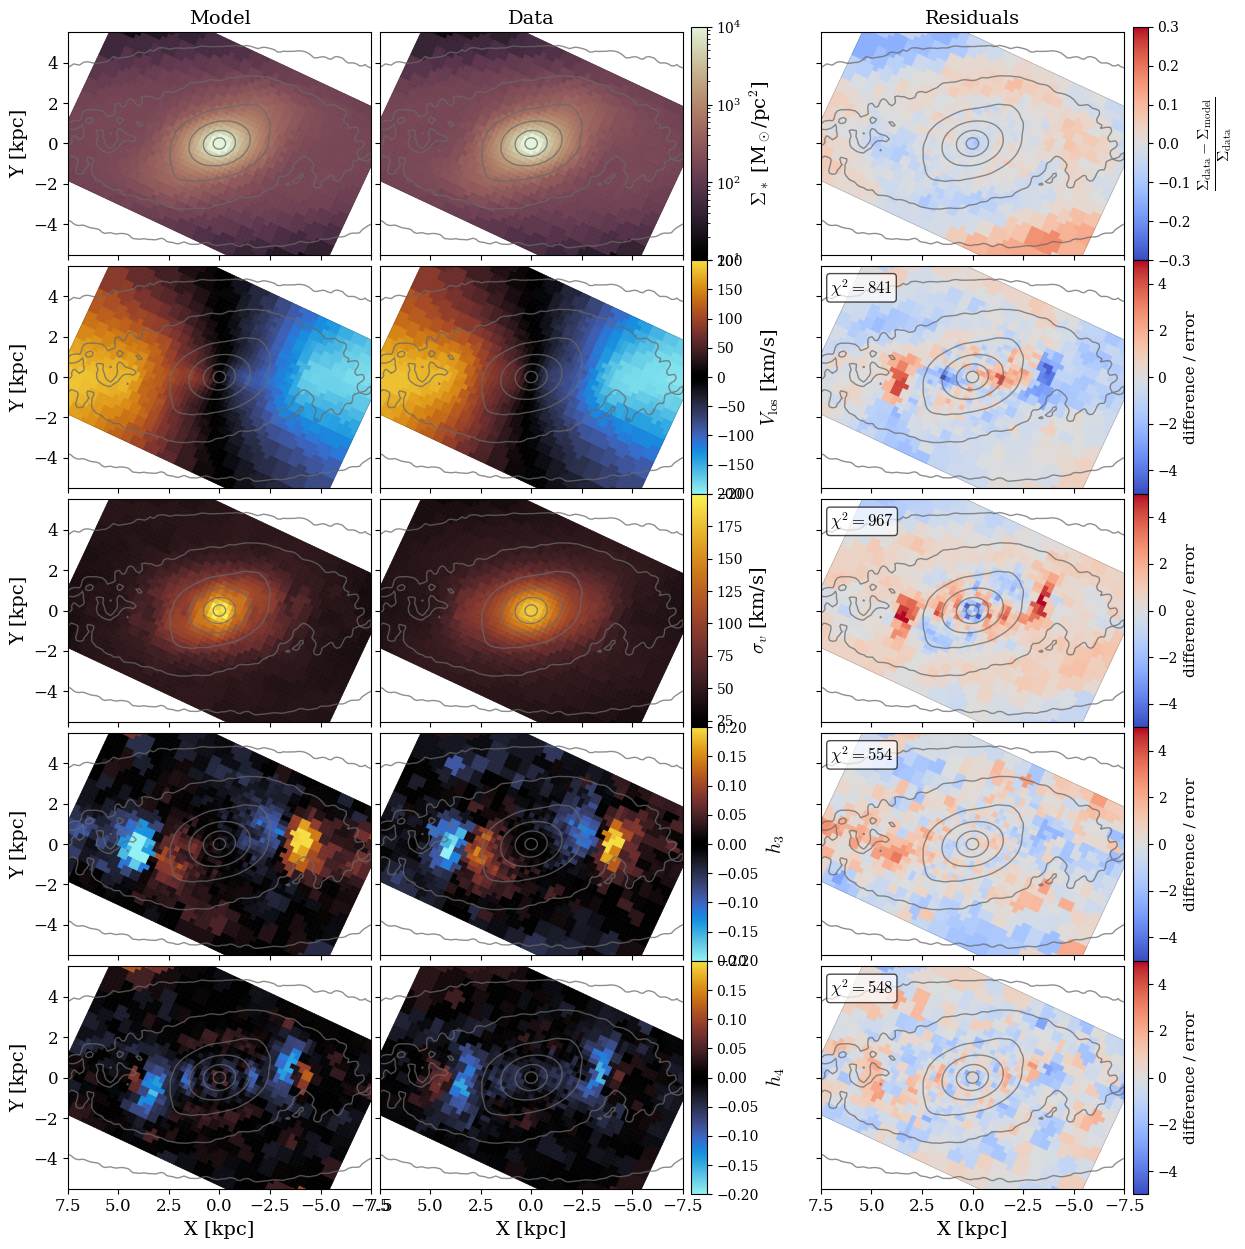

In [13]:
# --- 5x3 panel: rows (Sigma, V, sigma, h3, h4) x cols (Model, Data, Residual) ---
xlim = (-7.5, 7.5); ylim = (-5.5, 5.5)

panels = [
    (r'$\Sigma_*$ [M$_\odot$/pc$^2$]', y_xy,  density_model, cmap_Sigma, None,   1e1, 1e4,  0.30, chi2_dict['Sigma']),
    (r'$V_{\rm los}$ [km/s]',           y_V,   V_model,       cmap_V,     5.0,   -200, 200,  5.0,  chi2_dict['V']),
    (r'$\sigma_v$ [km/s]',              y_sig, sigma_model,   cmap_sig,   5.0,    20, 200,  5.0,  chi2_dict['sigma']),
    (r'$h_3$',                           y_h3,  h3_model,      cmap_V,     sig_h3,-0.2, 0.2,  5.0,  chi2_dict['h3']),
    (r'$h_4$',                           y_h4,  h4_model,      cmap_V,     sig_h4,-0.2, 0.2,  5.0,  chi2_dict['h4']),
]
n_rows = len(panels)
panel_h = (ylim[1] - ylim[0])
panel_w = (xlim[1] - xlim[0])
asp = panel_h / panel_w

fig_w = 12.0
panel_axis_w = (fig_w * 0.88) / (3.0 + 2 * 0.05 + 0.18)
fig_h = panel_axis_w * asp * n_rows / 0.92
fig = plt.figure(figsize=(fig_w, fig_h))
gs = gridspec.GridSpec(
    n_rows, 6, width_ratios=[1, 1, 0.05, 0.32, 1, 0.05],
    hspace=0.0, wspace=0.05,
    left=0.06, right=0.96, top=0.96, bottom=0.05,
)

def _make_pc(vals_pix, cmap, vmin, vmax, log_norm=False):
    if log_norm:
        pc = PolyCollection(pix_polys, array=vals_pix, cmap=cmap,
                            edgecolors='face', linewidths=0.5,
                            antialiased=True, rasterized=True,
                            norm=LogNorm(vmin=vmin, vmax=vmax))
    else:
        pc = PolyCollection(pix_polys, array=vals_pix, cmap=cmap,
                            edgecolors='face', linewidths=0.5,
                            antialiased=True, rasterized=True)
        pc.set_clim(vmin, vmax)
    return pc

def _draw_contour(ax):
    xm, ym, log10H, levels = contour
    ax.contour(xm, ym, log10H.T, levels=levels,
               colors='dimgrey', linewidths=1, alpha=0.75)

def _style_axes(ax, is_last_row, is_first_col):
    ax.set_xlim(xlim[1], xlim[0]); ax.set_ylim(ylim); ax.set_aspect('equal')
    if is_last_row:
        ax.set_xlabel('X [kpc]', fontsize=14)
    else:
        ax.set_xticklabels([])
    if is_first_col:
        ax.set_ylabel('Y [kpc]', fontsize=14)
    else:
        ax.set_yticklabels([])

for i, (label, data_b, model_b, cmap, err_b, vmin, vmax, res_scale, chi2_val) in enumerate(panels):
    data_pix  = to_pix(np.asarray(data_b))
    model_pix = to_pix(np.asarray(model_b))
    if err_b is None:
        res = (data_pix - model_pix) / np.maximum(np.abs(data_pix), 1e-12)
        res_label = r'$\frac{\Sigma_{\rm data} - \Sigma_{\rm model}}{\Sigma_{\rm data}}$'
    elif np.isscalar(err_b):
        res = (data_pix - model_pix) / err_b
        res_label = 'difference / error'
    else:
        res = (data_pix - model_pix) / (to_pix(np.asarray(err_b)) + 1e-12)
        res_label = 'difference / error'

    is_log = (i == 0); is_last = (i == n_rows - 1)
    ax_M  = fig.add_subplot(gs[i, 0]); ax_D = fig.add_subplot(gs[i, 1])
    cax_M = fig.add_subplot(gs[i, 2])
    ax_R  = fig.add_subplot(gs[i, 4]); cax_R = fig.add_subplot(gs[i, 5])

    pc_M = _make_pc(model_pix, cmap, vmin, vmax, log_norm=is_log)
    pc_D = _make_pc(data_pix,  cmap, vmin, vmax, log_norm=is_log)
    ax_M.add_collection(pc_M); ax_D.add_collection(pc_D)
    cb = fig.colorbar(pc_D, cax=cax_M); cb.set_label(label, fontsize=14)
    cb.ax.tick_params(labelsize=10)

    pc_R = _make_pc(res, 'coolwarm', -res_scale, res_scale, log_norm=False)
    ax_R.add_collection(pc_R)
    cb = fig.colorbar(pc_R, cax=cax_R)
    cb.set_label(res_label, fontsize=(16 if i==0 else 11))
    cb.ax.tick_params(labelsize=10)

    for ax in (ax_M, ax_D, ax_R):
        _draw_contour(ax)
        ax.plot(corners_fig[0], corners_fig[1], color='k', lw=0.4, alpha=0.25)
    if i == 0:
        ax_M.set_title('Model', fontsize=14)
        ax_D.set_title('Data',  fontsize=14)
        ax_R.set_title('Residuals', fontsize=14)

    _style_axes(ax_M, is_last, is_first_col=True)
    _style_axes(ax_D, is_last, is_first_col=False)
    _style_axes(ax_R, is_last, is_first_col=False)

    if i != 0:
        ax_R.text(0.03, 0.95, rf'$\chi^2 = {chi2_val:.0f}$',
                  transform=ax_R.transAxes, fontsize=12, va='top', ha='left',
                  bbox=dict(boxstyle='round,pad=0.2',
                            facecolor='white', edgecolor='black', alpha=0.7))

plt.show()


## 3. Rotation curve + DM enclosed mass

In [14]:
# --- posterior sweep for the rotation-curve band ---
DISCARD_ROT = 500
THIN_ROT    = 2
FILTER_LOGP_GAP_ROT = 100.0

last_lp = all_logprob[-1, :]
keep_rot = last_lp > (last_lp.max() - FILTER_LOGP_GAP_ROT)
posterior_rot = all_samples[:, keep_rot, :][DISCARD_ROT::THIN_ROT, :, :].reshape(-1, 12)
print(f'Kept {keep_rot.sum()}/{all_samples.shape[1]} chains, '
      f'posterior shape after discard+thin: {posterior_rot.shape}')

r_plot = np.linspace(0.01, 20.0, 100)
n_phi = 10
phi_grid = np.linspace(0.0, 2*np.pi, n_phi)

# v_c(R) at phi != 0 isn't directly supported by get_rotation_curve
# (which evaluates at phi=0). Make a tiny wrapper that re-uses the
# same finite-difference logic at arbitrary phi.
@partial(jax.jit, static_argnames=('potential_fn',))
def get_vc_alongphi(R, potential_fn, potential_args, z, phi, dR=1e-3):
    R = jnp.asarray(R)
    R_shape = R.shape
    R_flat = jnp.ravel(R)
    R_safe = jnp.maximum(jnp.abs(R_flat), 2 * dR)

    def phi_of_R(r):
        x, y = r * jnp.cos(phi), r * jnp.sin(phi)
        return potential_fn(x, y, z, *potential_args)

    def dphi_dr(r):
        return (phi_of_R(r + dR) - phi_of_R(r - dR)) / (2.0 * dR)

    dPhi_dR = jax.vmap(dphi_dr)(R_safe)
    vc2 = jnp.maximum(R_safe * dPhi_dR, 0.0)
    return jnp.reshape(jnp.sqrt(vc2) * KPCGYR_TO_KMS, R_shape)


def vc_curve_for_theta(theta):
    p_halo, p_baryon = unpack_params(theta)
    vc_phi = []
    for ph in phi_grid:
        _vc = jax.vmap(get_vc_alongphi, in_axes=(0, None, None, 0, None))(
            jnp.asarray(r_plot), potential_func,
            (p_baryon, p_halo),
            jnp.zeros_like(r_plot), ph,
        )
        vc_phi.append(np.asarray(_vc))
    return np.mean(vc_phi, axis=0)


Vc_model = np.zeros((posterior_rot.shape[0], len(r_plot)))
for i in tqdm(range(posterior_rot.shape[0]), desc='v_c band'):
    Vc_model[i] = vc_curve_for_theta(posterior_rot[i])

vc16, vc50, vc84 = np.percentile(Vc_model, [16, 50, 84], axis=0)


Kept 32/32 chains, posterior shape after discard+thin: (8000, 12)


v_c band: 100%|██████████| 8000/8000 [00:59<00:00, 133.98it/s]


In [16]:
# --- ground-truth v_c from the AGAMA CylSpline potential ---
agama.setUnits(mass=1, length=1, velocity=1)
pot_nbody = agama.Potential(NBODY_POT_INI)
print('Loaded AGAMA potential from', NBODY_POT_INI)

def vc_agama(R):
    pos = np.column_stack([R, R*0, R*0])
    f = pot_nbody.force(pos)
    return np.sqrt(np.maximum(-R * f[:, 0], 0.0))

vc_truth = vc_agama(r_plot)


Loaded AGAMA potential from /Users/hanyuan/Library/CloudStorage/Dropbox/python_script/schwarmax_pkg/example/Bar_model_TG21/model/t_t0_7.ini


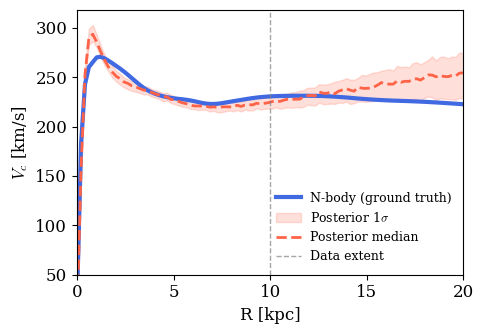

In [17]:
# --- rotation-curve figure ---
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(r_plot, vc_truth, lw=3, color='royalblue', label='N-body (ground truth)')
ax.fill_between(r_plot, vc16, vc84, color='tomato', alpha=0.2,
                label=r'Posterior 1$\sigma$')
ax.plot(r_plot, vc50, lw=2, ls='--', color='tomato', label='Posterior median')
ax.axvline(10., color='grey', ls='--', lw=1, alpha=0.7, label='Data extent')
ax.set_xlim(0., 20.); ax.set_ylim(50, None)
ax.set_xlabel('R [kpc]'); ax.set_ylabel(r'$V_c$ [km/s]')
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


In [18]:
# --- DM enclosed mass: NFW analytic from posterior median ---
DISCARD_ENC = 500
THIN_ENC    = 30
posterior_enc = all_samples[:, keep_rot, :][DISCARD_ENC::THIN_ENC, :, :].reshape(-1, 12)
print(f'M(<r) posterior shape after discard+thin: {posterior_enc.shape}')

r_enc = np.logspace(np.log10(0.3), np.log10(30), 500)

def nfw_M_enclosed(r, logM, Rs):
    M = 10.0 ** logM
    x = r / Rs
    return M * (np.log(1 + x) - x / (1 + x))

M_dm = np.zeros((posterior_enc.shape[0], len(r_enc)))
for i in tqdm(range(posterior_enc.shape[0]), desc='M_DM band'):
    p_halo, _ = unpack_params(posterior_enc[i])
    M_dm[i] = nfw_M_enclosed(r_enc, p_halo['logM'], p_halo['Rs'])

M16, M50, M84 = np.percentile(M_dm, [16, 50, 84], axis=0)


M(<r) posterior shape after discard+thin: (544, 12)


M_DM band: 100%|██████████| 544/544 [00:00<00:00, 15345.05it/s]


In [19]:
# --- N-body halo M(<r) ---
# Load the snapshot, centre it the same way as Section 2, but keep only
# halo-tagged particles (the heaviest-mass tag).
from astropy import units as u
from astropy.constants import G

agama.setUnits(length=1, velocity=1, mass=1)
mass_unit = 1 / ((G * u.Msun).to(u.kpc * (u.km / u.s)**2))
w0_full, mass_full = agama.readSnapshot(NBODY_SNAPSHOT)
mass_full = mass_full * mass_unit.value
mask_halo = (mass_full == np.unique(mass_full)[-1])
mask_disc_full = ~mask_halo
# Centre on disc particles (shrinking aperture) so the halo is in the
# same frame as the disc-aligned plot in Section 2.
for r_ap in [5.0, 5.0]:
    R = np.sqrt(w0_full[:, 0]**2 + w0_full[:, 1]**2)
    mc = mask_disc_full & (R < r_ap)
    m_c = mass_full[mc]
    for col in range(6):
        w0_full[:, col] -= np.sum(w0_full[mc, col] * m_c) / np.sum(m_c)

w0_halo = w0_full[mask_halo]; m_halo = mass_full[mask_halo]
r_halo = np.sqrt(np.sum(w0_halo[:, :3]**2, axis=1))
order = np.argsort(r_halo)
cum_halo = np.cumsum(m_halo[order])
M_dm_truth = np.interp(r_enc, r_halo[order], cum_halo)
print(f'Total halo particles: {mask_halo.sum()}, total halo mass: {m_halo.sum():.3e} Msun')


Total halo particles: 1000000, total halo mass: 8.722e+11 Msun


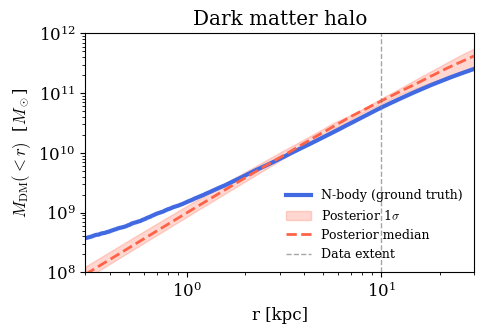

In [20]:
# --- M_DM enclosed figure ---
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(r_enc, M_dm_truth, lw=3, color='royalblue', label='N-body (ground truth)')
ax.fill_between(r_enc, M16, M84, color='tomato', alpha=0.25,
                label=r'Posterior 1$\sigma$')
ax.plot(r_enc, M50, lw=2, ls='--', color='tomato', label='Posterior median')
ax.axvline(10., color='grey', ls='--', lw=1, alpha=0.7, label='Data extent')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(r_enc[0], r_enc[-1])
ax.set_ylim(1e8, 1e12)
ax.set_xlabel('r [kpc]'); ax.set_ylabel(r'$M_{\rm DM}(<r)$  [$M_\odot$]')
ax.set_title('Dark matter halo')
ax.legend(frameon=False, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


## 4. Orbital structure

Run `get_model_with_orbit` to get full 6-D trajectories, then compute the
circularity \lambda_z = L_z / L_{\rm circ}(E) at every accepted
integration step.

The figure compares P(\lambda_z | log R) for the N-body disc, the
best-fit orbital library, and their difference.


In [21]:
# --- best-fit parameters for orbital library (DISCARD=600, median of the filtered chain) ---
DISCARD_ORB = 600
posterior_orb = all_samples[:, keep_rot, :][DISCARD_ORB:, :, :].reshape(-1, 12)
best_theta_orb = np.median(posterior_orb, axis=0)
print(f'Orbital posterior samples after DISCARD={DISCARD_ORB}: {posterior_orb.shape[0]}')
print('Median theta:', np.round(best_theta_orb, 4))

p_halo_orb, p_baryon_orb = unpack_params(best_theta_orb)


Orbital posterior samples after DISCARD=600: 12800
Median theta: [10.8693 11.1125 10.2274  0.7185  1.3342 -0.1314  0.67    0.4373  1.1489
  0.8592 -0.2232  1.4242]


In [22]:
# --- run the forward model with trajectory storage ---
print('Running get_model_with_orbit (~80 s for JIT compile + integration)...')
import time
t0 = time.time()
orb_dict = get_model_with_orbit(
    density_func, potential_func,
    p_halo_orb, p_baryon_orb, dict_data,
    num_Vbin=dict_data['total_bins'],
    Rzphi_n_tot=dict_data['Rzphi_n_tot'],
    Rzphi_n_grid=dict_data['Rzphi_n_grid'],
    Rzphi_lim_grid=Rzphi_lim_grid,
    xy_lim_grid=xy_lim_grid, xy_n_grid=xy_n_grid,
    nnls_maxiter=200, regularization=1.0,
)
orb_dict['y_traj'].block_until_ready()
print(f'  done in {time.time()-t0:.1f} s')

weights      = np.asarray(orb_dict['weights'])              # (n_particles,)
y_traj       = np.asarray(orb_dict['y_traj'])               # (n_particles, 1, N_max, 6)
t_traj       = np.asarray(orb_dict['t_traj'])               # (n_particles, 1, N_max)
print(f'weights shape: {weights.shape}, y_traj shape: {y_traj.shape}')
print(f'sum of weights: {weights.sum():.3e}')


Running get_model_with_orbit (~80 s for JIT compile + integration)...
  done in 80.8 s
weights shape: (10000,), y_traj shape: (10000, 1, 5000, 6)
sum of weights: 9.635e+03


In [23]:
# --- extract weighted (x, y, z, vx, vy, vz) samples at every accepted timestep ---
# Apply 4-fold bar symmetry: replicate every sample with 4 sign patterns.
SIGN_SYM = np.array([
    [ 1,  1,  1,  1,  1,  1],
    [ 1,  1, -1,  1,  1, -1],
    [-1, -1,  1, -1, -1,  1],
    [-1, -1, -1, -1, -1, -1],
], dtype=np.float32)

n_part, n_real, N_max, _ = y_traj.shape
y_flat = y_traj.reshape(-1, N_max, 6)              # (n_part*n_real, N_max, 6)
t_flat = t_traj.reshape(-1, N_max)
w_flat = np.repeat(weights, n_real)                # (n_part*n_real,)

# Per-orbit dt = t[i+1] - t[i]; only steps with dt > 0 are accepted.
dt_flat = np.diff(t_flat, axis=1, prepend=t_flat[:, :1])   # (n_orbits, N_max)
accepted = dt_flat > 0

# Flatten across (orbit, timestep) and apply symmetry.
y_acc = y_flat[accepted]                                    # (N_acc, 6)
w_acc = (dt_flat * w_flat[:, None])[accepted]               # (N_acc,) — dt * orbit weight

# Subsample to keep memory bounded.
N_SAMPLE_PER_SYM = 2_500_000
rng = np.random.default_rng(2024)
if y_acc.shape[0] > N_SAMPLE_PER_SYM:
    idx = rng.choice(y_acc.shape[0], size=N_SAMPLE_PER_SYM, replace=False)
    y_acc = y_acc[idx]; w_acc = w_acc[idx]

# Apply the 4 bar-symmetry sign patterns.
y_sym = (y_acc[None, :, :] * SIGN_SYM[:, None, :]).reshape(-1, 6)
w_sym = np.tile(w_acc, 4)
print(f'Model samples after symmetry: {y_sym.shape[0]:,}')

x_m, y_m, z_m, vx_m_kpcgyr, vy_m_kpcgyr, vz_m_kpcgyr = y_sym.T

# Visualisation jitter (matches plot_orbital_structure.py): ~0.1 kpc on
# positions, ~10% of local v_c (clipped to [1, 15] km/s) on velocities.
# This smooths the histogram in regions where samples are sparse — same
# trick the published figure uses. Comment out if you want the raw bins.
_R_for_vc = np.sqrt(x_m**2 + y_m**2)
_Vc_local = np.asarray(jax.vmap(get_vc_alongphi, in_axes=(0, None, None, 0, None))(
    jnp.asarray(_R_for_vc), potential_func,
    (p_baryon_orb, p_halo_orb), jnp.asarray(z_m), 0.0,
))
d_scale = 0.1 * np.ones_like(_R_for_vc)
v_scale_kms = np.clip(0.1 * _Vc_local, 1.0, 15.0)
v_scale_kpcgyr = v_scale_kms / KPCGYR_TO_KMS

rng_jit = np.random.default_rng(2024)
x_m  = x_m  + rng_jit.standard_normal(x_m.size)  * d_scale
y_m  = y_m  + rng_jit.standard_normal(y_m.size)  * d_scale
z_m  = z_m  + rng_jit.standard_normal(z_m.size)  * d_scale
vx_m_kpcgyr = vx_m_kpcgyr + rng_jit.standard_normal(vx_m_kpcgyr.size) * v_scale_kpcgyr
vy_m_kpcgyr = vy_m_kpcgyr + rng_jit.standard_normal(vy_m_kpcgyr.size) * v_scale_kpcgyr
vz_m_kpcgyr = vz_m_kpcgyr + rng_jit.standard_normal(vz_m_kpcgyr.size) * v_scale_kpcgyr

R_model = np.sqrt(x_m**2 + y_m**2)


Model samples after symmetry: 10,000,000


In [24]:
# --- model-side circularity ---
Lcirc_interp, _, _ = build_Lcirc_of_E(potential_func, (p_baryon_orb, p_halo_orb))

# Energy of each sample (model potential, internal units kpc^2/Gyr^2)
Phi_model_vmap = jax.vmap(potential_func, in_axes=(0, 0, 0, None, None))
Phi_chunks = []
chunk = 200_000
for i in range(0, x_m.size, chunk):
    Phi_chunks.append(np.asarray(Phi_model_vmap(
        jnp.asarray(x_m[i:i+chunk]),
        jnp.asarray(y_m[i:i+chunk]),
        jnp.asarray(z_m[i:i+chunk]),
        p_baryon_orb, p_halo_orb,
    )))
Phi_model = np.concatenate(Phi_chunks)
print('Potential eval done')

v2_internal = vx_m_kpcgyr**2 + vy_m_kpcgyr**2 + vz_m_kpcgyr**2     # kpc^2/Gyr^2
E_model     = 0.5 * v2_internal + Phi_model
Lz_model_internal = -(x_m * vy_m_kpcgyr - y_m * vx_m_kpcgyr)       # kpc^2/Gyr

Lcirc_model = np.asarray(Lcirc_interp(E_model))
lam_model = Lz_model_internal / (Lcirc_model + 1e-10)


Potential eval done


In [25]:
# --- N-body circularity from the AGAMA potential ---
mask_disc_pure = (mass_full != np.unique(mass_full)[-1])
w0_disc = w0_full[mask_disc_pure]
mass_disc = mass_full[mask_disc_pure]

# Bar-align (same as Sections 2 & 3 do for the contour overlay)
w0_disc[:, 0] = -w0_disc[:, 0]; w0_disc[:, 3] = -w0_disc[:, 3]
R_mid_ba, bar_angles_ba = bar_angle_bar_strength(
    w0_disc[:, 0], w0_disc[:, 1], R_annulus=np.arange(1, 5, 0.1))
bar_angle_disc = float(np.mean(bar_angles_ba[R_mid_ba < 4]))
c_ba, s_ba = np.cos(-bar_angle_disc), np.sin(-bar_angle_disc)
xx, yy, zz, vxx, vyy, vzz = w0_disc.T
w0_disc = np.array([xx*c_ba - yy*s_ba, xx*s_ba + yy*c_ba, zz,
                    vxx*c_ba - vyy*s_ba, vxx*s_ba + vyy*c_ba, vzz]).T

pos_disc = w0_disc[:, :3]; vel_disc = w0_disc[:, 3:]
R_disc = np.sqrt(pos_disc[:, 0]**2 + pos_disc[:, 1]**2)
Lz_disc = -(pos_disc[:, 0] * vel_disc[:, 1] - pos_disc[:, 1] * vel_disc[:, 0])
v2_disc = np.sum(vel_disc**2, axis=1)
Phi_disc = pot_nbody.potential(pos_disc)
E_disc = 0.5 * v2_disc + Phi_disc

R_circ_disc = pot_nbody.Rcirc(E=E_disc)
pos_circ = np.column_stack([R_circ_disc, np.zeros_like(R_circ_disc),
                            np.zeros_like(R_circ_disc)])
force_circ = pot_nbody.force(pos_circ)
Vc_circ = np.sqrt(np.maximum(R_circ_disc * (-force_circ[:, 0]), 0.0))
Lcirc_disc = R_circ_disc * Vc_circ
lam_disc = Lz_disc / (Lcirc_disc + 1e-10)
print(f'N-body disc particles for circularity: {pos_disc.shape[0]:,}')


N-body disc particles for circularity: 2,000,000


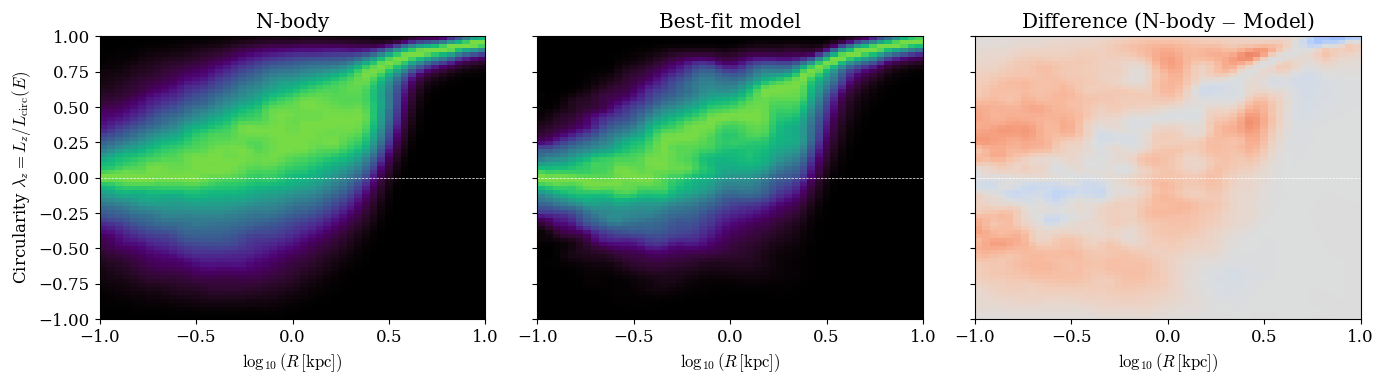


Mean |P_nbody - P_model| across all (logR, lambda) bins: 0.0687


In [26]:
# --- 3-panel (N-body | Model | Difference) ---
try:
    import cmasher as cmr
    cmap_lam = cmr.lavender
except ImportError:
    cmap_lam = 'magma'

import scipy.ndimage

R_cut_n = R_disc < 10
R_cut_m = R_model < 10
bins_R   = 50
bins_lam = 70
R_range = (-1., 1.)   # log10(R/kpc)
lam_range = (-1., 1.)

# N-body histogram
H_n, xe, ye = np.histogram2d(
    np.log10(R_disc[R_cut_n]), lam_disc[R_cut_n],
    bins=[bins_R, bins_lam], range=[R_range, lam_range],
    weights=mass_disc[R_cut_n],
)
H_n = scipy.ndimage.gaussian_filter(H_n, sigma=1.0)
col_norm = H_n / np.maximum(np.sum(H_n, axis=1, keepdims=True), 1e-30)
P_n = col_norm / np.maximum(np.amax(col_norm, axis=1, keepdims=True), 1e-30)

# Model histogram
H_m, _, _ = np.histogram2d(
    np.log10(R_model[R_cut_m]), lam_model[R_cut_m],
    bins=[bins_R, bins_lam], range=[R_range, lam_range],
    weights=w_sym[R_cut_m],
)
H_m = scipy.ndimage.gaussian_filter(H_m, sigma=1.0)
col_norm = H_m / np.maximum(np.sum(H_m, axis=1, keepdims=True), 1e-30)
P_m = col_norm / np.maximum(np.amax(col_norm, axis=1, keepdims=True), 1e-30)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

ax = axes[0]
ax.pcolormesh(xe, ye, P_n.T, cmap=cmap_lam, rasterized=True)
ax.set_xlabel(r'$\log_{10}(R \, [{\rm kpc}])$')
ax.set_ylabel(r'Circularity $\lambda_z = L_z / L_{\rm circ}(E)$')
ax.set_title('N-body')
for y in (0, 1, -1):
    ax.axhline(y, color='white', ls='--' if y==0 else ':', lw=0.5)

ax = axes[1]
ax.pcolormesh(xe, ye, P_m.T, cmap=cmap_lam, rasterized=True)
ax.set_xlabel(r'$\log_{10}(R \, [{\rm kpc}])$')
ax.set_title('Best-fit model')
for y in (0, 1, -1):
    ax.axhline(y, color='white', ls='--' if y==0 else ':', lw=0.5)

ax = axes[2]
ax.pcolormesh(xe, ye, (P_n - P_m).T, cmap='coolwarm', vmin=-0.5, vmax=0.5, rasterized=True)
ax.set_xlabel(r'$\log_{10}(R \, [{\rm kpc}])$')
ax.set_title('Difference (N-body $-$ Model)')
for y in (0, 1, -1):
    ax.axhline(y, color='white', ls='--' if y==0 else ':', lw=0.5)

plt.tight_layout()
plt.show()

mean_abs_diff = float(np.mean(np.abs(P_n - P_m)))
print(f'\nMean |P_nbody - P_model| across all (logR, lambda) bins: {mean_abs_diff:.4f}')
